# Feature Extraction

In this notebook we continue the Hagen-model workflow by loading CDM signals computed in Tutorial 2 (`Compute Field Potentials`) for `J_ext = 28, 30, 32` nA.

We will:
- load the CDM records from the tutorial output,
- compute `catch22` features for each `J_ext` to capture complementary properties of biological signals (time structure, statistics, and spectral-related descriptors),
- compute `specparam` descriptors that separate aperiodic and oscillatory components, focusing on slope and gamma peak frequency,
- visualize all 24 features (`22 + 2`) as a function of `J_ext` in a `6 x 4` subplot grid.


## Requirements

To run this notebook, install:
- `ncpi`
- `pycatch22`
- `specparam`

You also need the CDM sweep file generated from Tutorial 2:
- `examples/simulation/Hagen_model/simulation/output/tutorial_cdm_sweep.pkl`


### 1) Set up paths, imports, and helper utilities

This cell imports dependencies, locates the repository root automatically, and defines helper utilities for loading catch22 names and plotting feature trends.


In [1]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import ncpi


def find_repo_root(start_dir: Path) -> Path:
    for candidate in [start_dir, *start_dir.parents]:
        if (candidate / "examples" / "simulation" / "Hagen_model" / "simulation").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing examples/simulation/Hagen_model/simulation")


def get_catch22_names():
    try:
        import pycatch22
    except Exception as exc:
        raise ImportError("pycatch22 is required to fetch catch22 feature names.") from exc
    return pycatch22.catch22_all([0])["names"]


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SIM_ROOT = REPO_ROOT / "examples" / "simulation" / "Hagen_model" / "simulation"
OUTPUT_FOLDER = SIM_ROOT / "output"

print("Repo root:", REPO_ROOT)
print("Simulation root:", SIM_ROOT)
print("Output folder:", OUTPUT_FOLDER)


Repo root: /home/pablomc/OneDrive/2026/ncpi
Simulation root: /home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation
Output folder: /home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation/output


### 2) Load CDM sweeps from Tutorial 2

This cell loads the CDM signals generated in the field-potential tutorial and checks available `J_ext` values.


In [2]:
CDM_SWEEP_FILE = OUTPUT_FOLDER / "tutorial_cdm_sweep.pkl"

if not OUTPUT_FOLDER.exists():
    raise FileNotFoundError(f"Simulation output folder not found: {OUTPUT_FOLDER}")

if not CDM_SWEEP_FILE.exists():
    raise FileNotFoundError(
        f"Required CDM file not found: {CDM_SWEEP_FILE}. "
        "Run Tutorial 2 (Compute Field Potentials) with the updated notebook so it writes tutorial_cdm_sweep.pkl."
    )

with open(CDM_SWEEP_FILE, "rb") as handle:
    cdm_payload = pickle.load(handle)

if isinstance(cdm_payload, dict):
    cdm_records = cdm_payload.get("records", [])
elif isinstance(cdm_payload, list):
    cdm_records = cdm_payload
else:
    raise TypeError("Unsupported CDM payload type. Expected dict or list.")

if not cdm_records:
    raise ValueError("CDM payload does not contain any records.")

available_jext = [float(r["J_ext"]) for r in cdm_records]
print("Loaded J_ext values:", available_jext)
print("Loaded CDM file:", CDM_SWEEP_FILE)


Loaded J_ext values: [28.0, 30.0, 32.0]
Loaded CDM file: /home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation/output/tutorial_cdm_sweep.pkl


### 3) Compute `catch22` and `specparam` features from CDMs

For each `J_ext`, we compute:
- the full `catch22` vector (`22` features), capturing complementary aspects of the signal across time structure, statistics, and spectral-related behavior,
- `specparam` slope (aperiodic exponent),
- `specparam` center frequency (selected oscillatory peak; interpreted here as gamma peak frequency).


In [3]:
catch22_names = get_catch22_names()

catch22_extractor = ncpi.Features(method="catch22", params={"normalize": True})
specparam_extractor = ncpi.Features(
    method="specparam",
    params={
        "freq_range": (10.0, 200.0),
        "select_peak": "max_pw",
        "metric_policy": "flag",
        "specparam_model": {
            "peak_threshold": 1.0,
            "min_peak_height": 0.0,
            "max_n_peaks": 5,
            "peak_width_limits": (10.0, 50.0),
        },
    },
)

feature_rows = []

for record in sorted(cdm_records, key=lambda x: float(x["J_ext"])):
    j_ext = float(record["J_ext"])

    cdm_signal = record.get("cdm", record.get("cdm_norm", None))
    if cdm_signal is None:
        raise KeyError(
            "Each CDM record must contain either 'cdm' or 'cdm_norm'."
        )

    cdm_signal = np.asarray(cdm_signal, dtype=float).squeeze()

    fs_hz = record.get("fs_hz", None)
    if fs_hz is None:
        dt_ms = record.get("dt", None)
        if dt_ms is None:
            raise KeyError("Each CDM record must include either 'fs_hz' or 'dt'.")
        decim_q = int(record.get("decimation_q", record.get("decimation_factor", 1)))
        fs_hz = 1000.0 / (float(dt_ms) * float(decim_q))
    fs_hz = float(fs_hz)

    c22 = np.asarray(catch22_extractor.catch22(cdm_signal), dtype=float)
    sp = specparam_extractor.specparam(sample=cdm_signal, fs=fs_hz)

    aperiodic = np.asarray(sp.get("aperiodic_params", [np.nan, np.nan]), dtype=float)
    slope = float(aperiodic[1]) if aperiodic.size > 1 else np.nan
    center_frequency = float(sp.get("peak_cf", np.nan))

    feature_rows.append(
        {
            "J_ext": j_ext,
            "catch22": c22,
            "specparam_slope": slope,
            "specparam_center_frequency": center_frequency,
        }
    )

print("Computed feature rows:", len(feature_rows))
print("J_ext order:", [row["J_ext"] for row in feature_rows])


Computed feature rows: 3
J_ext order: [28.0, 30.0, 32.0]


### 4) Assemble a feature matrix (`22 + 2`)

This cell builds a single matrix where each column is one feature and each row corresponds to one `J_ext` condition.


In [4]:
j_ext_values = np.array([row["J_ext"] for row in feature_rows], dtype=float)

catch22_matrix = np.vstack([row["catch22"] for row in feature_rows])
specparam_matrix = np.column_stack(
    [
        [row["specparam_slope"] for row in feature_rows],
        [row["specparam_center_frequency"] for row in feature_rows],
    ]
)

feature_matrix = np.hstack([catch22_matrix, specparam_matrix])
feature_labels = catch22_names + ["specparam_slope", "specparam_center_frequency"]

print("Feature matrix shape:", feature_matrix.shape)
print("Number of labels:", len(feature_labels))


Feature matrix shape: (3, 24)
Number of labels: 24


### 5) Plot feature trends vs `J_ext` in a `6 x 4` panel

Each subplot shows one feature trajectory across the `J_ext` sweep.


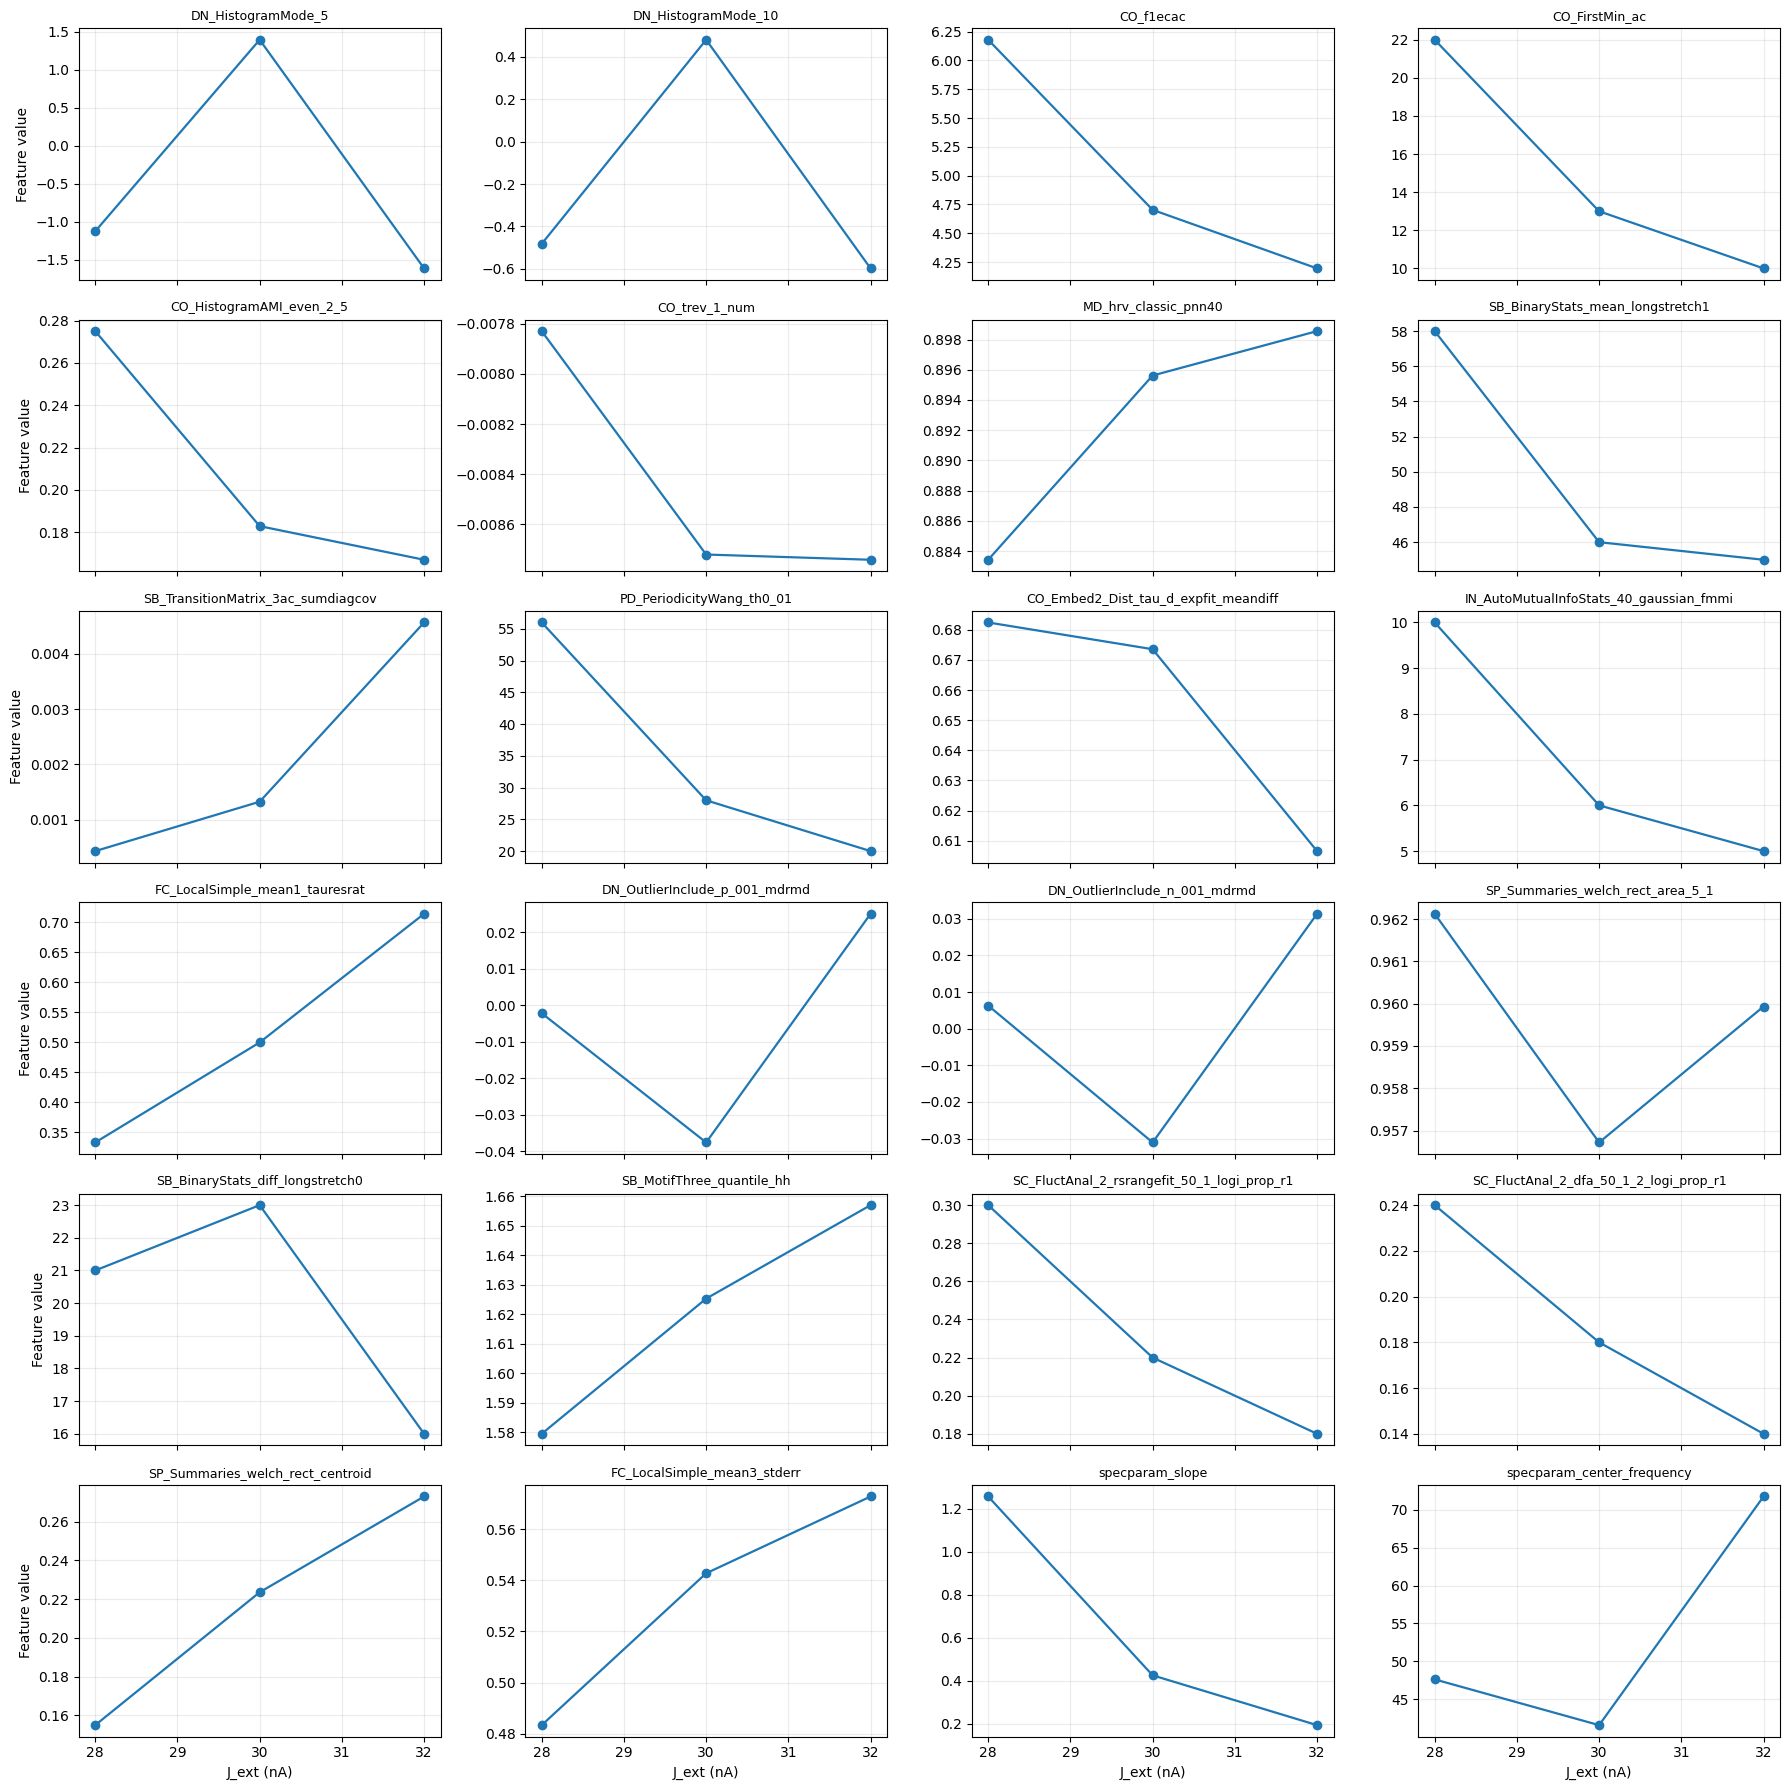

In [5]:
fig, axes = plt.subplots(6, 4, figsize=(18, 18), sharex=True)
axes_flat = axes.ravel()

for i, ax in enumerate(axes_flat):
    y = feature_matrix[:, i]
    ax.plot(j_ext_values, y, marker="o", lw=1.6, color="C0")
    ax.set_title(feature_labels[i], fontsize=9)
    ax.grid(True, alpha=0.25)

    if i % 4 == 0:
        ax.set_ylabel("Feature value")
    if i >= 20:
        ax.set_xlabel("J_ext (nA)")

plt.tight_layout()
plt.show()
